# Sprawozdanie L5 — SAC + HER (PandaReach-v3)

## Hiperparametry z `metadata.json`

dodałem do programu zapis wag, oraz możliowść wgrania ich tak aby nie odpalać treningu za każdym razem na nowo

In [3]:
meta_path = RUN_DIR / "metadata.json"
if not meta_path.is_file():
    raise FileNotFoundError(meta_path)

with meta_path.open(encoding="utf-8") as f:
    meta_doc = json.load(f)

sig = meta_doc["signature"]
print(json.dumps(sig, indent=2, ensure_ascii=False))

{
  "env_id": "PandaReach-v3",
  "eval_render": {
    "n_episodes": 50,
    "sleep": 0.03333333333333333
  },
  "format_version": 1,
  "her": {
    "goal_selection_strategy": "future",
    "n_sampled_goal": 3,
    "replay_buffer_size_load": 50000,
    "replay_buffer_size_train": 1000000
  },
  "policy": {
    "extractor": "DictExtractor",
    "hidden_sizes": [
      64,
      64
    ]
  },
  "sac": {
    "alpha": "auto",
    "batch_size": 64,
    "gamma": 0.9,
    "lr": 0.0001,
    "max_episode_len": 100,
    "n_test_episodes": 25,
    "n_updates": null,
    "polyak": 0.995,
    "seed": 0,
    "start_steps": 1000,
    "target_entropy": "auto",
    "update_after": 1000,
    "update_every": 1
  },
  "train_loop": {
    "log_interval": 1000,
    "n_steps": 100000
  }
}


## Implementacja — HER

Pełny moduł: [`asdf/buffers.py`](asdf/buffers.py) (klasa `HerReplayBuffer`). Poniżej źródło kluczowych metod: episodyczne zbieranie przejść, na końcu epizodu zapis z oryginalnym celem oraz `n_sampled_goal` wariantów z nowym `desired_goal` i nagrodą z `env.unwrapped.compute_reward`, strategia wyboru celu (`future` / `final` / `episode`).

In [4]:
import inspect

from asdf.buffers import HerReplayBuffer

print("--- HerReplayBuffer.end_episode ---\n")
print(inspect.getsource(HerReplayBuffer.end_episode))
print("\n--- HerReplayBuffer._sample_goal ---\n")
print(inspect.getsource(HerReplayBuffer._sample_goal))

--- HerReplayBuffer.end_episode ---

    def end_episode(self) -> None:
        ep = self._episode_transitions
        if not ep:
            return
        env_compute = self.env.unwrapped
        if not hasattr(env_compute, "compute_reward"):
            raise AttributeError(
                "HER requires env.unwrapped.compute_reward (goal-conditioned Gymnasium env)."
            )

        for t_idx, tr in enumerate(ep):
            self._store_one_transition(
                tr["observation"],
                tr["action"],
                tr["reward"],
                tr["next_observation"],
                tr["terminated"],
                tr["truncated"],
                tr["info"],
            )
            for _ in range(self.n_sampled_goal):
                new_goal = self._sample_goal(ep, t_idx)
                o = self._copy_obs(tr["observation"])
                o2 = self._copy_obs(tr["next_observation"])
                o["desired_goal"] = np.asarray(new_goal, dtype=np.flo

## Implementacja — automatyczne $\alpha$ w SAC

Pełny moduł: [`asdf/algos.py`](asdf/algos.py). Współczynnik temperatury entropii jest uczony jako `log_alpha` (optymalizacja Adam), zgodnie z sekcją *Automating Entropy Adjustment* w [SAC Algorithms and Applications](https://arxiv.org/abs/1812.05905). Poniżej: fragment `__init__` (inicjalizacja), `compute_loss_alpha` oraz krok w `update`.

In [5]:
import inspect

from asdf.algos import SAC

src_init = inspect.getsource(SAC.__init__)
needle = 'if isinstance(alpha, str) and alpha.startswith("auto"):'
i = src_init.find(needle)
if i < 0:
    raise RuntimeError("Nie znaleziono bloku auto-alpha w SAC.__init__")
print("--- SAC.__init__ (auto α) ---\n")
print(src_init[i:])

print("\n--- SAC.compute_loss_alpha ---\n")
print(inspect.getsource(SAC.compute_loss_alpha))

print("\n--- SAC.update (fragment: optymalizacja α) ---\n")
src_upd = inspect.getsource(SAC.update)
j = src_upd.find("# Optimize entropy coefficient")
print(src_upd[j:] if j >= 0 else src_upd)

--- SAC.__init__ (auto α) ---

if isinstance(alpha, str) and alpha.startswith("auto"):
            # Default initial value of alpha when learned
            init_value = 1.0
            if "_" in alpha:
                init_value = float(alpha.split("_")[1])
                assert (
                    init_value > 0.0
                ), "The initial value of alpha must be greater than 0"

            # Consider: optimizing the log of the entropy coeff which is slightly different from the paper
            # as discussed in https://github.com/rail-berkeley/softlearning/issues/37

            self.log_alpha = nn.Parameter(
                torch.tensor(
                    np.log(init_value), dtype=torch.float32, device=alpha_device
                )
            )
            self.alpha_optimizer = Adam([self.log_alpha], lr=lr)
            with torch.no_grad():
                self.alpha = self.log_alpha.exp().detach()
        else:
            # Force conversion to float
            # t

## Wyniki — krzywe z TensorBoard (`runs/`)

Wybierany jest **najnowszy** podkatalog w `runs/` (po czasie modyfikacji plików wewnątrz). Jeśli chcesz konkretny run, zmień zmienną `TB_RUN` w komórce poniżej (ścieżka do podkatalogu z `events.out.tfevents.*`).

TensorBoard: C:\Users\womackow\Zbiorczy\_WIN_AI_AGH_\WIN_sem_1\UMISI-sem1-RL\l5\runs\May24_16-31-25_80e32dcd8f99
Skalary: ['alpha', 'ep_length', 'ep_return', 'loss_alpha', 'loss_pi', 'loss_q', 'test_ep_length', 'test_ep_return']


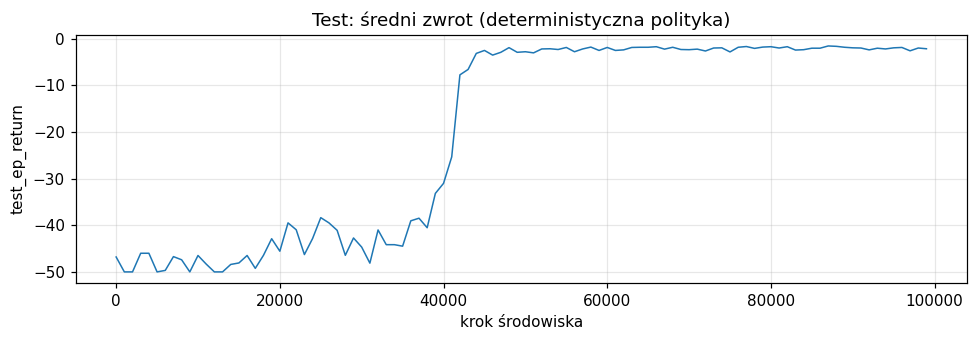

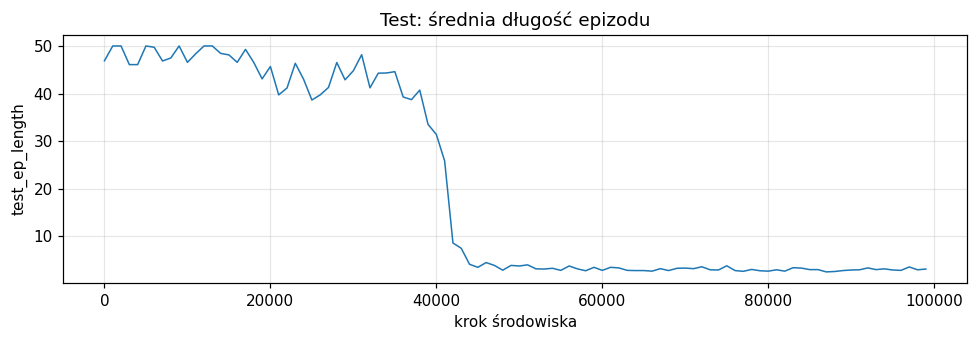

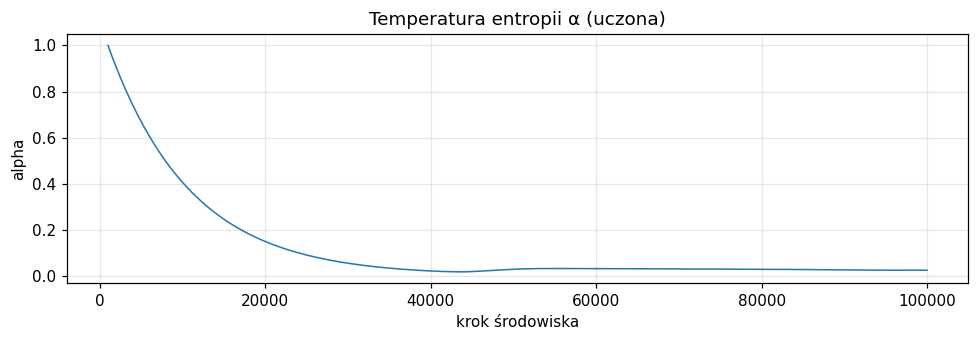

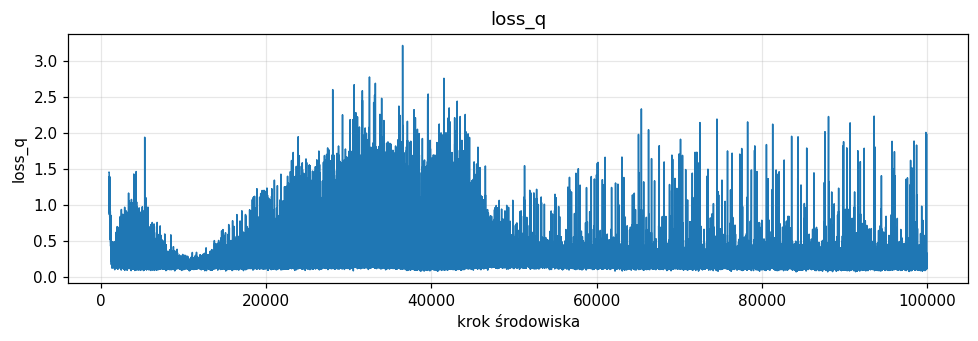

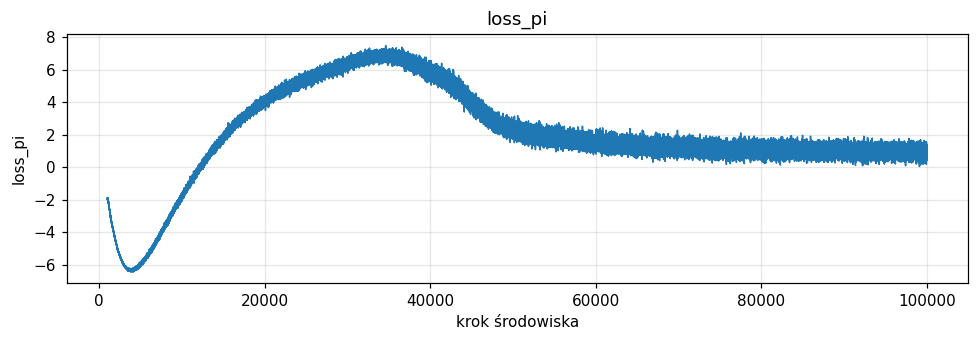

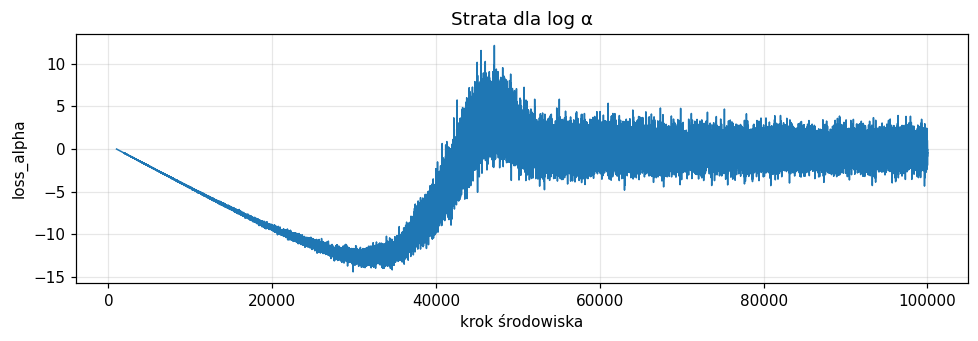

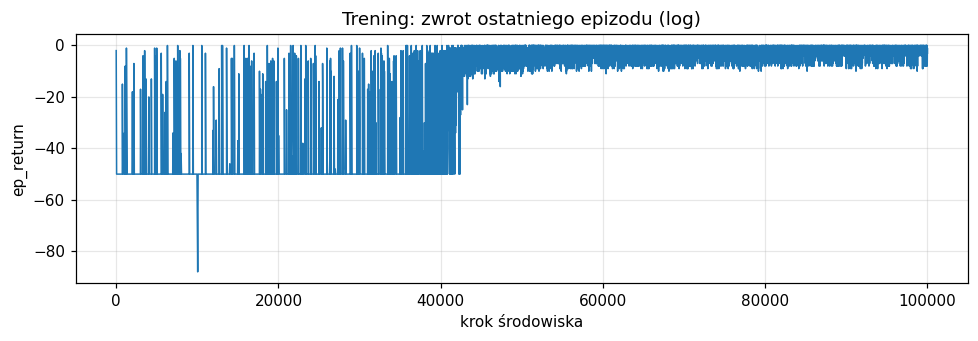

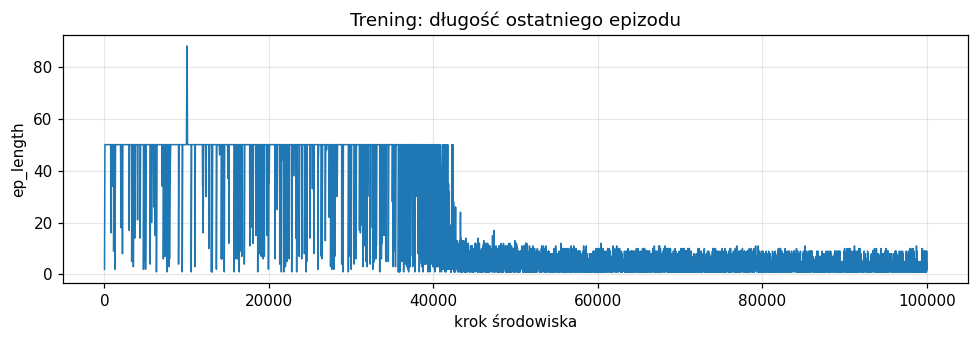

In [6]:
from tensorboard.backend.event_processing import event_accumulator as ea


def pick_latest_tensorboard_run(runs_dir: Path) -> Path:
    if not runs_dir.is_dir():
        raise FileNotFoundError(f"Brak katalogu TensorBoard: {runs_dir}")
    subs = [p for p in runs_dir.iterdir() if p.is_dir()]
    if not subs:
        raise FileNotFoundError(f"Brak podkatalogów w {runs_dir}")

    def latest_mtime(d: Path) -> float:
        files = list(d.glob("*"))
        if not files:
            return d.stat().st_mtime
        return max(f.stat().st_mtime for f in files)

    return max(subs, key=latest_mtime)


# Ustaw na None aby wybrać najnowszy; albo np. RUNS_DIR / "May24_12-00-00"
TB_RUN: Path | None = None
tb_run = TB_RUN or pick_latest_tensorboard_run(RUNS_DIR)
print("TensorBoard:", tb_run)

acc = ea.EventAccumulator(str(tb_run), size_guidance={"scalars": 0})
acc.Reload()
scalar_tags = acc.Tags().get("scalars", [])
print("Skalary:", sorted(scalar_tags))


def plot_scalar(tag: str, title: str | None = None) -> None:
    if tag not in scalar_tags:
        print(f"(brak tagu {tag!r})")
        return
    events = acc.Scalars(tag)
    steps = [e.step for e in events]
    vals = [e.value for e in events]
    plt.figure(figsize=(9, 3.2))
    plt.plot(steps, vals, lw=1)
    plt.xlabel("krok środowiska")
    plt.ylabel(tag)
    plt.title(title or tag)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plt.rcParams["figure.dpi"] = 110
plot_scalar("test_ep_return", "Test: średni zwrot (deterministyczna polityka)")
plot_scalar("test_ep_length", "Test: średnia długość epizodu")
plot_scalar("alpha", "Temperatura entropii α (uczona)")
plot_scalar("loss_q")
plot_scalar("loss_pi")
plot_scalar("loss_alpha", "Strata dla log α")
plot_scalar("ep_return", "Trening: zwrot ostatniego epizodu (log)")
plot_scalar("ep_length", "Trening: długość ostatniego epizodu")

## Wyniki — ewaluacja z checkpointu

Wczytanie `policy.pt` po weryfikacji `signature` względem `train.py` (`load_sac_from_run_dir`). Krótki test deterministyczny na tym samym `env_id` co trening.

Using CPU
Epizodów testowych: 50
  mean_ep_ret: -1.8600
  mean_ep_len: 2.8600
  success_rate: 1.0000


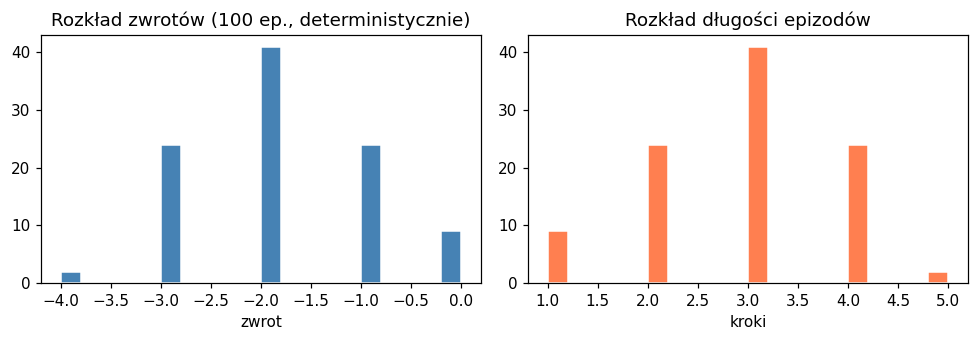

In [7]:
import gymnasium as gym
import panda_gym  # noqa: F401 — rejestracja środowisk

from train import load_sac_from_run_dir

env, algo, doc = load_sac_from_run_dir(RUN_DIR)
n_ep = 50
results = algo.test(env, n_episodes=n_ep, render=False)
env.close()

print(f"Epizodów testowych: {n_ep}")
for k, v in results.items():
    if isinstance(v, (float, np.floating, np.integer, int)):
        print(f"  {k}: {float(v):.4f}")


def eval_episode_returns(env_id: str, algo, n_episodes: int, seed: int = 0) -> tuple[list[float], list[int]]:
    rng = np.random.default_rng(seed)
    env_e = gym.make(env_id)
    rets, lens = [], []
    try:
        for _ in range(n_episodes):
            obs, _ = env_e.reset(seed=int(rng.integers(0, 2**31 - 1)))
            done, ep_ret, ep_len = False, 0.0, 0
            while not done and ep_len < algo.max_episode_len:
                a = algo.policy.act(obs, deterministic=True)
                obs, r, ter, tru, _ = env_e.step(a)
                ep_ret += float(r)
                ep_len += 1
                done = ter or tru
            rets.append(ep_ret)
            lens.append(ep_len)
    finally:
        env_e.close()
    return rets, lens


env_id = doc["signature"]["env_id"]
rets, lens = eval_episode_returns(env_id, algo, n_episodes=100)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(rets, bins=20, color="steelblue", edgecolor="white")
ax[0].set_title("Rozkład zwrotów (100 ep., deterministycznie)")
ax[0].set_xlabel("zwrot")
ax[1].hist(lens, bins=20, color="coral", edgecolor="white")
ax[1].set_title("Rozkład długości epizodów")
ax[1].set_xlabel("kroki")
plt.tight_layout()
plt.show()

## Porównanie współczynnika α (stały vs automatyczny)

Dla każdego pełnego treningu (`python train.py`) z **inną wartością `alpha`** w `SAC_KWARGS` w `train.py` powstaje osobny katalog `weights/...` (z `metadata.json`) oraz log TensorBoard w `runs/...`.

**Zalecane:** skrypt [`train_alpha_sweep.py`](train_alpha_sweep.py) uruchamia serię treningów (α = 0.05 … 0.99 oraz **na końcu** `alpha="auto"`), zapisuje wagi pod `weights/<sweep_id>/...`, logi TB pod `runs/<sweep_id>/alpha_.../` oraz w `metadata.json` pole **`tensorboard_log_dir`** (względem katalogu `l5/`). Wtedy komórka poniżej **nie potrzebuje** heurystyki czasu ani `MANUAL_TB_FOR_WEIGHTS`.

Poniższa komórka:

1. Wczytuje **wszystkie** `metadata.json` pod `weights/` (także zagnieżdżone), odczytuje **`alpha`** i opcjonalnie **`tensorboard_log_dir`**.
2. Jeśli brak `tensorboard_log_dir`, dopasowuje run TensorBoard po czasie modyfikacji `events.out.tfevents.*`.
3. Rysuje **słupki**: ostatnia wartość **`test_ep_return`** z TB vs ustawienie α.
4. Rysuje **α w czasie**: krzywa z runu z **`alpha` zaczynającym się od `"auto"`** oraz **poziome linie** dla stałych α z pozostałych metadanych.

Domyślnie sweep **kończy się runem** `alpha="auto"` (baseline z uczoną temperaturą); żeby go pominąć: `python train_alpha_sweep.py --skip-auto`. Heurystyczne dopasowanie TB lub **`MANUAL_TB_FOR_WEIGHTS`** — tylko dla starych runów bez pola `tensorboard_log_dir` w JSON.

Runy wag / dopasowanie TB:
  2026-05-24_16-53        alpha=auto          TB=BRAK                                      Δt=—


C:\Users\womackow\AppData\Local\Temp\ipykernel_31016\4076429222.py:141: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = plt.cm.get_cmap("tab10")


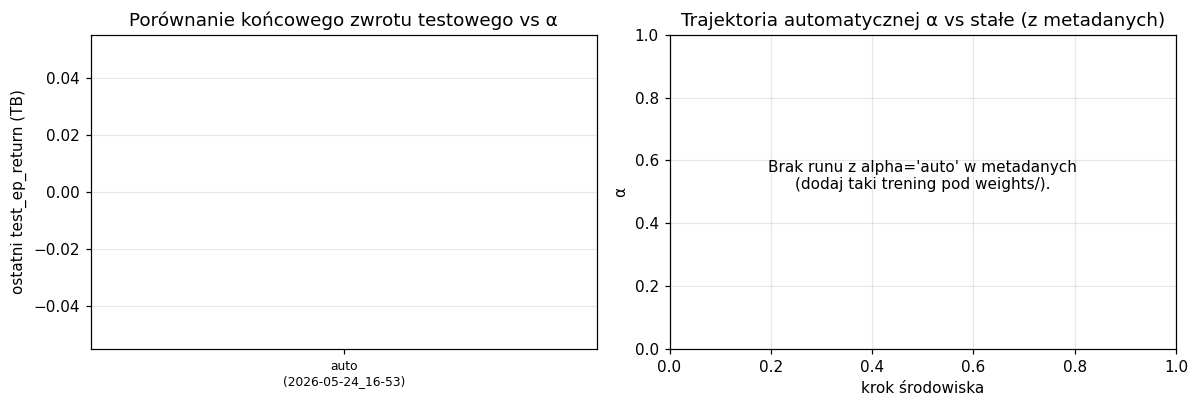

In [8]:
from __future__ import annotations

from datetime import datetime, timezone
from tensorboard.backend.event_processing import event_accumulator as ea

# Opcjonalnie: nadpisanie dopasowania TB — klucz = nazwa podkatalogu w weights/ (np. "2026-05-24_16-53")
MANUAL_TB_FOR_WEIGHTS: dict[str, Path] = {}


def _tb_event_mtimes(tb_dir: Path) -> tuple[float, float]:
    """(min, max) mtime plików events w runie TB."""
    ev = list(tb_dir.glob("events.out.tfevents.*")) + list(tb_dir.glob("**/events.out.tfevents.*"))
    if not ev:
        t = tb_dir.stat().st_mtime
        return t, t
    mt = [f.stat().st_mtime for f in ev]
    return min(mt), max(mt)


def _list_tb_run_dirs(runs_dir: Path) -> list[Path]:
    if not runs_dir.is_dir():
        return []
    return [p for p in runs_dir.iterdir() if p.is_dir()]


def _open_tb_accumulator(tb_dir: Path) -> ea.EventAccumulator:
    acc = ea.EventAccumulator(str(tb_dir), size_guidance={"scalars": 0})
    acc.Reload()
    return acc


def _last_scalar(acc: ea.EventAccumulator, tag: str) -> float | None:
    tags = acc.Tags().get("scalars", [])
    if tag not in tags:
        return None
    ev = acc.Scalars(tag)
    return float(ev[-1].value) if ev else None


def _alpha_series(acc: ea.EventAccumulator) -> tuple[list[int], list[float]] | None:
    if "alpha" not in acc.Tags().get("scalars", []):
        return None
    ev = acc.Scalars("alpha")
    return [e.step for e in ev], [float(e.value) for e in ev]


def _fmt_alpha(a) -> str:
    if isinstance(a, str):
        return a if a.startswith("auto") else repr(a)
    return f"{float(a):g}"


def collect_weight_runs(weights_root: Path) -> list[dict]:
    """Wszystkie ``metadata.json`` pod ``weights_root`` (także zagnieżdżone, np. sweep α)."""
    out = []
    if not weights_root.is_dir():
        return out
    for meta in sorted(weights_root.rglob("metadata.json")):
        sub = meta.parent
        doc = json.loads(meta.read_text(encoding="utf-8"))
        sig = doc.get("signature") or {}
        sac = sig.get("sac") or {}
        raw = sac.get("alpha", "?")
        saved_s = doc.get("saved_at_utc") or ""
        try:
            saved = datetime.fromisoformat(saved_s.replace("Z", "+00:00"))
        except ValueError:
            saved = datetime.fromtimestamp(sub.stat().st_mtime, tz=timezone.utc)
        rel_w = str(sub.resolve().relative_to(weights_root.resolve())).replace("\\", "/")
        out.append(
            {
                "weights_name": rel_w,
                "weights_dir": sub,
                "alpha_raw": raw,
                "alpha_label": _fmt_alpha(raw),
                "saved_ts": saved.timestamp(),
                "saved_dt": saved,
                "tensorboard_rel": doc.get("tensorboard_log_dir"),
            }
        )
    return out


def pair_tb_to_weights(
    rows: list[dict],
    runs_dir: Path,
    *,
    max_delta_sec: float = 3 * 3600,
) -> list[dict]:
    tb_dirs = _list_tb_run_dirs(runs_dir)
    tb_info = []
    for p in tb_dirs:
        mn, mx = _tb_event_mtimes(p)
        tb_info.append({"path": p, "mtime_lo": mn, "mtime_hi": mx})

    used: set[Path] = set()
    paired = []
    for r in sorted(rows, key=lambda x: x["saved_ts"]):
        manual = MANUAL_TB_FOR_WEIGHTS.get(r["weights_name"])
        if manual is not None and manual.is_dir():
            paired.append({**r, "tb_dir": manual.resolve(), "pair_delta_sec": 0.0})
            used.add(manual.resolve())
            continue

        tr = r.get("tensorboard_rel")
        if tr:
            tb_path = (L5_ROOT / Path(tr)).resolve()
            if tb_path.is_dir():
                paired.append({**r, "tb_dir": tb_path, "pair_delta_sec": 0.0})
                used.add(tb_path)
                continue

        t_end = r["saved_ts"]
        best: tuple[float, Path] | None = None
        for tb in tb_info:
            p = tb["path"]
            rp = p.resolve()
            if rp in used:
                continue
            # TB zwykle kończy się tuż przed zapisem wag; bierzemy odległość końca TB od zapisu
            delta = abs(t_end - tb["mtime_hi"])
            if best is None or delta < best[0]:
                best = (delta, rp)

        if best is not None and best[0] <= max_delta_sec:
            used.add(best[1])
            paired.append({**r, "tb_dir": best[1], "pair_delta_sec": best[0]})
        else:
            paired.append({**r, "tb_dir": None, "pair_delta_sec": float("nan")})
    return paired


rows = collect_weight_runs(L5_ROOT / "weights")
paired = pair_tb_to_weights(rows, RUNS_DIR)

print("Runy wag / dopasowanie TB:")
for p in paired:
    tb = p["tb_dir"]
    dt = p["pair_delta_sec"]
    dt_s = f"{float(dt):.0f}s" if dt == dt and np.isfinite(dt) else "—"
    print(
        f"  {p['weights_name']:22}  alpha={p['alpha_label']!s:12}  TB="
        f"{tb.name if tb else 'BRAK':<40}  Δt={dt_s}"
    )

# --- wykresy ---
paired_sorted = sorted(paired, key=lambda x: (str(x["alpha_label"]), x["weights_name"]))
tab10 = plt.cm.get_cmap("tab10")

auto_tb: Path | None = None
auto_label: str | None = None
auto_candidates = [
    p
    for p in paired
    if isinstance(p["alpha_raw"], str)
    and str(p["alpha_raw"]).startswith("auto")
    and p.get("tb_dir") is not None
]
if auto_candidates:
    best_auto = max(auto_candidates, key=lambda x: x["saved_ts"])
    auto_tb = best_auto["tb_dir"]
    auto_label = best_auto["alpha_label"]

fixed_for_hlines: list[tuple[str, float]] = []
for p in paired:
    ar = p["alpha_raw"]
    if isinstance(ar, str) and ar.startswith("auto"):
        continue
    if isinstance(ar, bool):
        continue
    if isinstance(ar, (int, float)):
        af = float(ar)
        if not np.isfinite(af):
            continue
        fixed_for_hlines.append((p["alpha_label"], af))

vals: list[float] = []
labels: list[str] = []
colors: list[tuple] = []
label_to_color: dict[str, tuple] = {}

for i, p in enumerate(paired_sorted):
    lab = p["alpha_label"]
    if lab not in label_to_color:
        label_to_color[lab] = tab10(i % 10)
    col = label_to_color[lab]
    labels.append(f"{lab}\n({p['weights_name']})")
    colors.append(col)
    tb = p["tb_dir"]
    if tb is None:
        vals.append(float("nan"))
        continue
    acc = _open_tb_accumulator(tb)
    v = _last_scalar(acc, "test_ep_return")
    vals.append(v if v is not None else float("nan"))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axb = axes[0]
x = np.arange(len(labels))
axb.bar(x, vals, color=colors, edgecolor="white")
axb.set_xticks(x)
axb.set_xticklabels(labels, fontsize=8, rotation=0)
axb.set_ylabel("ostatni test_ep_return (TB)")
axb.set_title("Porównanie końcowego zwrotu testowego vs α")
axb.grid(True, axis="y", alpha=0.3)

axa = axes[1]
plotted_auto = False
if auto_tb is not None:
    acc_a = _open_tb_accumulator(auto_tb)
    ser = _alpha_series(acc_a)
    if ser:
        steps, av = ser
        axa.plot(steps, av, color="black", lw=1.2, label=f"α uczona ({auto_label or 'auto'})")
        plotted_auto = True
    else:
        axa.text(0.5, 0.5, "Brak skalara alpha w TB", ha="center", va="center", transform=axa.transAxes)
else:
    axa.text(
        0.5,
        0.55,
        "Brak runu z alpha='auto' w metadanych\n(dodaj taki trening pod weights/).",
        ha="center",
        va="center",
        transform=axa.transAxes,
        fontsize=10,
    )

for lab, a0 in fixed_for_hlines:
    c = label_to_color.get(lab, (0.5, 0.5, 0.5, 1.0))
    axa.axhline(a0, color=c, ls="--", lw=1.0, alpha=0.85, label=f"stała α = {lab}")

axa.set_xlabel("krok środowiska")
axa.set_ylabel("α")
axa.set_title("Trajektoria automatycznej α vs stałe (z metadanych)")
axa.grid(True, alpha=0.3)
if plotted_auto or fixed_for_hlines:
    axa.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

## Analiza i wnioski

### Środowisko i ustawienia HER

- Zadanie **PandaReach-v3** ma nagrodę opartą o odległość do `desired_goal`; bez HER wiele trajektorii daje bardzo mało sygnału uczącego.
- W eksperymencie użyto strategii **`future`** oraz **`n_sampled_goal` = 3** (patrz `signature` w komórce z `metadata.json`): dla każdego kroku epizodu, oprócz zapisu z prawdziwym celem, do bufora trafiają dodatkowe przejścia z **przekształconym** `desired_goal` (losowy `achieved_goal` z „przyszłości” epizodu) i **przeliczoną** nagrodą z `compute_reward`. To zwiększa gęstość przykładów dla sieci Q i polityki.

### Automatyczne $\alpha$

- Krzywa **`alpha`** (TensorBoard) pokazuje, jak temperatura entropii dostosowuje się do skali log-prawdopodobieństwa akcji względem zadanego `target_entropy` (tu: „auto”, czyli $-\dim \mathcal{A}$).
- **`loss_alpha`** oscyluje wokół zera, gdy średnie $\log \pi$ zbliża się do $-H_\text{target}$ — to oczekiwane przy poprawnie zestrojonym automacie.

### Wyniki liczbowe

- We wcześniejszej komórce ewaluacji wypisywane są m.in. **średni zwrot**, **średnia długość epizodu** i **success rate** z deterministycznego `algo.test`. Warto zestawić te wartości z ostatnim odczytem krzywej **`test_ep_return`** w TensorBoard (plateau lub spadek pod koniec treningu).
- Porównanie kilku ustawień **α** (stała temperatura vs. automatyczna) jest w sekcji **Porównanie współczynnika α** bezpośrednio powyżej.

### Wyzwania implementacyjne

- **Bufor episodyczny:** przejścia są składowane do `end_episode`; na końcu `train()` jest flush ostatniego epizodu — bez tego część danych HER nie trafiłaby do bufora.
- **Zgodność metadanych:** `train.py --load` wymaga identycznej sygnatury z `metadata.json` — zmiana hiperparametrów w kodzie unieważnia stare wagi.
- **Render:** pełny pipeline z `render_mode="human"` wymaga display / `xvfb-run` (opis w `README.md` w Dockerze).

### Dalsza praca (opcjonalnie)

- Inne środowiska z komentarza w `train.py` (np. `FetchReach-v3`, `PandaPush-v3`) — inna dynamika; HER bywa tam szczególnie przydatny.